# Loading DataSets


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Path to folders
train_path = "potato_data/Potato/Train"
val_path = "potato_data/Potato/Valid"
test_path = "potato_data/Potato/Test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
print("Detected classes:", class_names)

Found 900 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Detected classes: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


# Data Augmentation

In [4]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
])

# Build Train Model

In [ ]:
# Create the base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.6978 - loss: 0.7335 - val_accuracy: 0.8767 - val_loss: 0.3845
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9233 - loss: 0.2701 - val_accuracy: 0.9433 - val_loss: 0.2301
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9589 - loss: 0.1780 - val_accuracy: 0.9567 - val_loss: 0.1783
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.9667 - loss: 0.1372 - val_accuracy: 0.9633 - val_loss: 0.1513
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9733 - loss: 0.1142 - val_accuracy: 0.9667 - val_loss: 0.1349
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9744 - loss: 0.1011 - val_accuracy: 0.9700 - val_loss: 0.1199
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.9811 - loss: 0.0867 - val_accuracy: 0.9733 - val_loss: 0.1081
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.9789 - loss: 0.0818 - val_accuracy: 0.9767 - val_loss:

# Graph Results

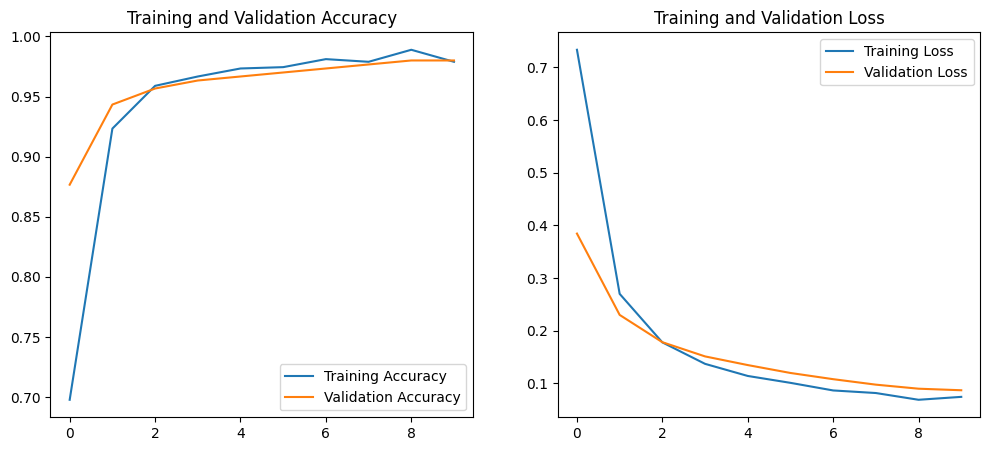

In [7]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 836ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- Classification Report ---
                       precision    recall  f1-score   support

Potato___Early_blight       0.98      1.00      0.99       100
 Potato___Late_blight       0.99      0.96      0.97       100
     Potato___healthy       0.98      0.99      0.99       100

             accuracy                           0.98       300
            macro avg       0.98      0.98      0.98       300
         weighted avg       0.98      0.98      0.98       300



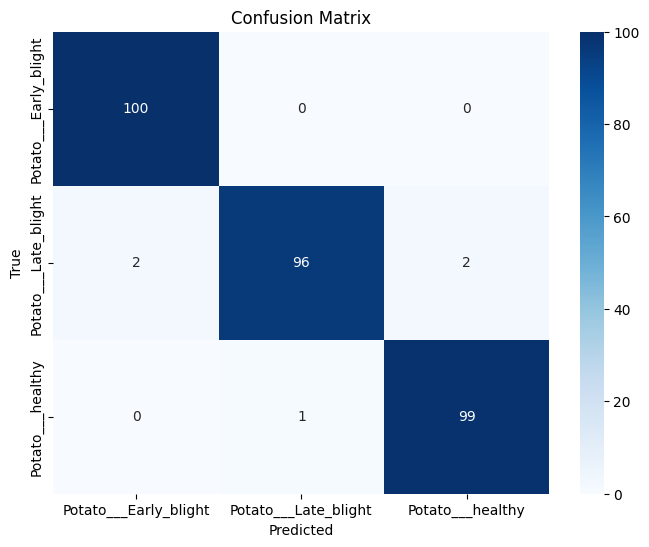

In [12]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Get all labels and predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print the F1-Score, Precision, and Recall
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Plot a Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Test Evaluation

In [9]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 632ms/step - accuracy: 0.9833 - loss: 0.0707

Test Accuracy: 98.33%


In [10]:
print("Class indices mapping:", class_names)

Class indices mapping: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


# Save the Model

## Saving the model this way is very risky because it includes the data augmentation to its layer

In [11]:
model.save('potato_disease_model_v2.h5')
print("Model saved as potato_disease_model_v2.h5")

Model saved as potato_disease_model_v2.h5


## Try The transfer weights saving

In [ ]:
final_model = tf.keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(3, activation='softmax')
])

# Transfer the weights from your trained model
final_model.set_weights(model.get_weights())
final_model.save('potato_model_v2_clean.h5')